## Conclusion

This notebook focused on detecting and analyzing high-demand pickup hotspots in New York City using aggregated taxi trip data. The primary objective was to transform raw trip-level records into meaningful spatial intelligence that can support operational decision-making and geospatial visualization in the next phase of the project.

The analysis began with validating the dataset, which already contained pre-engineered spatial and temporal features such as pickup hour, day of the week, month, and weekend indicators, along with official NYC taxi zone mappings (PULocationID, Zone, and Borough). This ensured that the dataset was clean and directly suitable for hotspot analysis without requiring additional feature engineering.

The core transformation in this notebook involved aggregating trip-level data at the zone level to compute total pickup counts for each taxi zone. This step converted millions of individual ride records into a structured demand profile for each geographic region in New York City.

From this aggregated data, several important insights were derived:

### 1. Spatial Demand Concentration
The analysis revealed that taxi pickup demand is highly unevenly distributed across the city. A small number of zones account for a disproportionately large share of total pickups. Manhattan emerged as the dominant borough in terms of taxi demand, significantly outperforming all other regions.

Within Manhattan, zones such as Midtown, Upper East Side, and surrounding commercial and residential districts consistently showed the highest pickup volumes. Additionally, airport-related zones, particularly JFK Airport, also emerged as strong demand centers outside the Manhattan core.

### 2. Demand Contribution and Inequality
The demand contribution analysis showed a strong skew in distribution, where top-performing zones contribute a large percentage of overall taxi activity, while the majority of zones have relatively low pickup counts. This confirms that taxi demand in NYC follows a highly concentrated (Pareto-like) distribution pattern.

### 3. Hotspot Classification
Using a quantile-based approach, zones were categorized into four distinct hotspot levels: Low, Medium, High, and Very High. This classification provides a business-friendly interpretation of demand intensity and allows clear prioritization of zones based on their operational importance.

The results clearly identified a small group of “Very High” demand zones that consistently dominate taxi activity and represent critical operational hotspots.

### 4. Operational Insights
The hotspot detection results highlight key areas where taxi demand is consistently high. These include central business districts, residential-commercial mixed zones, entertainment hubs, and major transportation nodes.

The findings indicate that effective fleet allocation strategies should prioritize these high-demand zones to improve service efficiency, reduce passenger waiting times, and optimize driver distribution.

### Overall Conclusion
This notebook successfully transformed raw NYC taxi trip data into a structured hotspot detection framework. By aggregating and analyzing pickup demand at the zone level, we identified clear spatial patterns of taxi utilization and classified zones based on demand intensity.

The analysis confirmed that taxi demand is highly concentrated in a small number of geographic regions, with Manhattan serving as the primary demand center and several key zones functioning as persistent hotspots. The use of a quantile-based classification approach enabled meaningful segmentation of zones into different operational priority levels.

These results provide a strong analytical foundation for the next stage of the project, where interactive geospatial visualizations will be developed to map and explore these hotspots in detail. Ultimately, this work supports data-driven decision-making in fleet management, urban mobility planning, and demand optimization strategies within New York City’s taxi ecosystem.

---
---

## Problem Statement

After completing exploratory data analysis, we observed that NYC taxi demand is not uniformly distributed across the city. Certain zones such as Midtown Manhattan, Upper East Side, and JFK Airport consistently show high pickup activity.

However, EDA only shows patterns — it does NOT clearly define:

- Which zones are actual “hotspots”
- How intense each hotspot is
- Which zones should be prioritized operationally
- Which areas contribute disproportionately to demand

Therefore, we need a systematic method to **detect and classify pickup hotspots**.

This notebook transforms raw pickup data into:

✔ Ranked hotspot zones  
✔ Demand intensity levels  
✔ Operational priority zones  
✔ Data foundation for spatial visualization (Notebook 4)

## Objective

The objective of this notebook is to:

1. Identify high-demand pickup zones using frequency-based analysis
2. Rank zones based on pickup volume
3. Measure each zone’s contribution to total citywide demand
4. Classify zones into hotspot intensity levels
5. Prepare structured output for geospatial visualization (heatmaps & Folium maps)

## Methodology Selection

Since the dataset contains:

- PULocationID
- Zone
- Borough
- No direct latitude/longitude usage in modeling stage

We choose a **frequency-based hotspot detection approach**.

### Why not clustering methods?

- K-Means → Requires coordinates
- DBSCAN → Requires spatial distance matrix
- KDE → Needs continuous spatial fields
- Graph-based methods → Complex adjacency modeling

### Why frequency-based method?

✔ Works directly on aggregated pickup counts  
✔ Highly interpretable for business users  
✔ Industry-standard for demand hotspot detection  
✔ Scalable for large taxi datasets  

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 2. Load Processed Dataset

In [3]:
df = pd.read_parquet("/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE3_Pickup_hotspot_Detection/data/processed_pickup_hotspot_data.parquet")
df.head()

,tpep_pickup_datetime,PULocationID,LocationID,Borough,Zone,service_zone,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2026-01-01 00:54:04,239,239,Manhattan,Upper West Side South,Yellow Zone,0,Thursday,1,0
1,2026-01-01 00:34:04,163,163,Manhattan,Midtown North,Yellow Zone,0,Thursday,1,0
2,2026-01-01 00:57:06,43,43,Manhattan,Central Park,Yellow Zone,0,Thursday,1,0
3,2026-01-01 00:15:22,142,142,Manhattan,Lincoln Square East,Yellow Zone,0,Thursday,1,0
4,2026-01-01 00:27:13,88,88,Manhattan,Financial District South,Yellow Zone,0,Thursday,1,0


## Dataset Overview

This dataset contains NYC taxi trip records with:

- PULocationID → pickup zone ID
- Zone → zone name
- Borough → city borough
- pickup_datetime → timestamp

From this, we derive spatial demand patterns.

## 3. Understand Dataset Structure

In [4]:
df.sample(10)

,tpep_pickup_datetime,PULocationID,LocationID,Borough,Zone,service_zone,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
2446458,2026-01-30 00:05:50,74,74,Manhattan,East Harlem North,Boro Zone,0,Friday,1,0
1682894,2026-01-20 16:22:51,161,161,Manhattan,Midtown Center,Yellow Zone,16,Tuesday,1,0
713240,2026-01-09 20:13:27,161,161,Manhattan,Midtown Center,Yellow Zone,20,Friday,1,0
3445254,2026-01-25 21:19:12,107,107,Manhattan,Gramercy,Yellow Zone,21,Sunday,1,1
3470776,2026-01-26 21:19:42,161,161,Manhattan,Midtown Center,Yellow Zone,21,Monday,1,0
1963837,2026-01-23 13:17:41,161,161,Manhattan,Midtown Center,Yellow Zone,13,Friday,1,0
2199726,2026-01-27 12:37:00,141,141,Manhattan,Lenox Hill West,Yellow Zone,12,Tuesday,1,0
400822,2026-01-06 13:41:42,186,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,13,Tuesday,1,0
3153985,2026-01-17 23:30:51,249,249,Manhattan,West Village,Yellow Zone,23,Saturday,1,1
1437492,2026-01-17 15:07:27,239,239,Manhattan,Upper West Side South,Yellow Zone,15,Saturday,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3718959 entries, 0 to 3718958
Data columns (total 10 columns):
 #   Column                Dtype         
---  ------                -----         
 0   tpep_pickup_datetime  datetime64[us]
 1   PULocationID          int32         
 2   LocationID            int64         
 3   Borough               object        
 4   Zone                  object        
 5   service_zone          object        
 6   pickup_hour           int32         
 7   pickup_dayofweek      object        
 8   pickup_month          int32         
 9   is_weekend            int64         
dtypes: datetime64[us](1), int32(3), int64(2), object(4)
memory usage: 241.2+ MB


In [6]:
df.isnull().sum()

tpep_pickup_datetime    0
PULocationID            0
LocationID              0
Borough                 0
Zone                    0
service_zone            0
pickup_hour             0
pickup_dayofweek        0
pickup_month            0
is_weekend              0
dtype: int64

We perform data inspection to ensure:

- No missing zone mappings
- Timestamp is correctly formatted
- Dataset is clean for aggregation

## 4. ## Validate Data Consistency

In [8]:
df["Borough"].value_counts()

Borough
Manhattan        3180607
Queens            344826
Brooklyn          155668
Bronx              36886
Staten Island        486
EWR                  486
Name: count, dtype: int64

In [9]:
df["Zone"].nunique()

259

In [10]:
df["PULocationID"].nunique()

260

We ensure:
- Zones are properly mapped
- No missing spatial labels
- Data is ready for hotspot detection

## Aggregate Pickup Demand by Zone

In [11]:
zone_demand = (
    df.groupby(["PULocationID", "Zone", "Borough"])
    .size()
    .reset_index(name="pickup_count")
)

We convert trip-level data → zone-level demand summary:

Each row now represents:
- One zone
- Total number of pickups in that zone

## Sort Zones by Pickup Volume

In [12]:
zone_demand = zone_demand.sort_values("pickup_count", ascending=False)
zone_demand.head(10)

,PULocationID,Zone,Borough,pickup_count
233,237,Upper East Side South,Manhattan,160343
232,236,Upper East Side North,Manhattan,153640
128,132,JFK Airport,Queens,152589
157,161,Midtown Center,Manhattan,146641
182,186,Penn Station/Madison Sq West,Manhattan,110700
138,142,Lincoln Square East,Manhattan,110004
158,162,Midtown East,Manhattan,108703
226,230,Times Sq/Theatre District,Manhattan,106114
78,79,East Village,Manhattan,100998
235,239,Upper West Side South,Manhattan,97465


## Compute Contribution of Each Zone

In [13]:
total_pickups = zone_demand["pickup_count"].sum()

zone_demand["demand_percentage"] = (
    zone_demand["pickup_count"] / total_pickups
) * 100

This tells us:
- Which zones dominate NYC taxi demand
- How skewed the distribution is

## Classify Hotspot Levels (Business Categorization)

In [14]:
zone_demand["hotspot_level"] = pd.qcut(
    zone_demand["pickup_count"],
    q=[0, 0.70, 0.90, 0.95, 1],
    labels=["Low", "Medium", "High", "Very High"]
)

Taxi demand is highly skewed, so we use quantiles to:

- Automatically adapt to distribution
- Avoid arbitrary thresholds
- Create business-friendly categories

## Top 20 Pickup Hotspots

In [15]:
top_hotspots = zone_demand.head(20)
top_hotspots

,PULocationID,Zone,Borough,pickup_count,demand_percentage,hotspot_level
233,237,Upper East Side South,Manhattan,160343,4.311502,Very High
232,236,Upper East Side North,Manhattan,153640,4.131264,Very High
128,132,JFK Airport,Queens,152589,4.103003,Very High
157,161,Midtown Center,Manhattan,146641,3.943066,Very High
182,186,Penn Station/Madison Sq West,Manhattan,110700,2.976639,Very High
138,142,Lincoln Square East,Manhattan,110004,2.957925,Very High
158,162,Midtown East,Manhattan,108703,2.922942,Very High
226,230,Times Sq/Theatre District,Manhattan,106114,2.853325,Very High
78,79,East Village,Manhattan,100998,2.715760,Very High
235,239,Upper West Side South,Manhattan,97465,2.620760,Very High


## Demand Distribution by Borough

In [16]:
borough_demand = (
    zone_demand.groupby("Borough")["pickup_count"]
    .sum()
    .reset_index()
    .sort_values("pickup_count", ascending=False)
)

This helps identify:
- Which borough dominates taxi activity
- Spatial concentration of demand

## Top 10 Hotspots Visualization

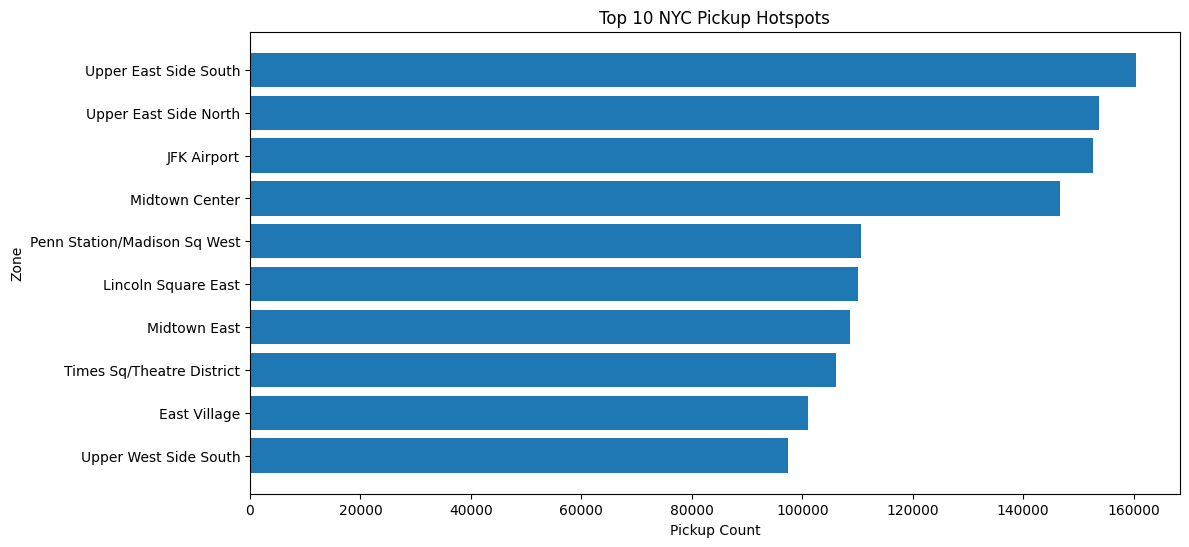

In [17]:
plt.figure(figsize=(12,6))

top10 = zone_demand.head(10)

plt.barh(top10["Zone"], top10["pickup_count"])
plt.gca().invert_yaxis()

plt.title("Top 10 NYC Pickup Hotspots")
plt.xlabel("Pickup Count")
plt.ylabel("Zone")

plt.show()

## Key Observations

- Taxi demand is highly concentrated in a small number of zones
- Manhattan dominates overall pickup activity
- Midtown and Upper East Side are consistent hotspots
- Airports act as strong secondary demand centers
- Distribution follows a strong skewed (Pareto) pattern

In [18]:
# Save zone-level hotspot data for next notebook
zone_demand.to_csv("/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/USECASE3_Pickup_hotspot_Detection/data/zone_hotspot_data.csv", index=False)